# Solution 3D: Prediction Quality Over Time
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_parquet("merged.parquet")
df = df[df["month"] >= "2023-01"].copy()
print(f"Loaded: {len(df):,} rows, {df['ticker'].nunique()} tickers")

FEATURES = ["momentum", "lag_month", "pb", "roe", "grossmargin",
            "assetturnover", "leverage", "asset_growth", "gp_to_assets"]

Loaded: 103,931 rows, 3866 tickers


In [2]:
# Rank features and target cross-sectionally each month
for feat in FEATURES:
    df[f"{feat}_rank"] = df.groupby("month")[feat].transform(lambda x: x.rank(pct=True))
df["ret_rank"] = df.groupby("month")["return"].transform(lambda x: x.rank(pct=True))
feat_rank_cols = [f"{f}_rank" for f in FEATURES]

# Train/test split
train = df[(df["month"] >= "2023-01") & (df["month"] <= "2024-12")].copy()
test = df[df["month"] >= "2025-01"].copy()
X_train = train[feat_rank_cols].values
y_train = train["ret_rank"].values
X_test = test[feat_rank_cols].values
print(f"Train: {len(train):,} rows ({train['month'].min()} to {train['month'].max()})")
print(f"Test:  {len(test):,} rows ({test['month'].min()} to {test['month'].max()})")

Train: 73,496 rows (2023-01 to 2024-12)
Test:  30,435 rows (2025-01 to 2025-11)


In [3]:
def compute_monthly_spearman(predictions, df_subset):
    df_sub = df_subset.copy()
    df_sub["pred"] = predictions
    result = {}
    for m, grp in df_sub.groupby("month"):
        if len(grp) > 10:
            rho, _ = spearmanr(grp["pred"], grp["return"])
            result[m] = rho
    return pd.Series(result).sort_index()

In [4]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

# Fit all four models
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.001, max_iter=10000).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1).fit(X_train, y_train)
lgbm = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                          random_state=42, verbosity=-1, n_jobs=-1).fit(X_train, y_train)

all_sp = {
    "Ridge": compute_monthly_spearman(ridge.predict(X_test), test),
    "Lasso": compute_monthly_spearman(lasso.predict(X_test), test),
    "Random Forest": compute_monthly_spearman(rf.predict(X_test), test),
    "LightGBM": compute_monthly_spearman(lgbm.predict(X_test), test),
}

## 1. Monthly Spearman correlation over time

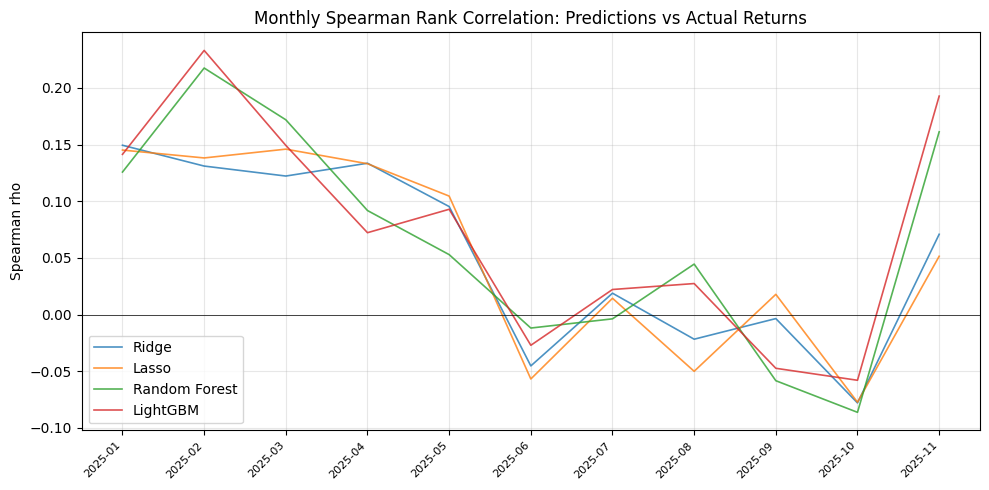

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, sp in all_sp.items():
    ax.plot(range(len(sp)), sp.values, label=name, alpha=0.8, linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Monthly Spearman Rank Correlation: Predictions vs Actual Returns")
ax.set_ylabel("Spearman rho")
ax.legend()
ax.grid(True, alpha=0.3)
ref = list(all_sp.values())[0]
ticks = list(range(0, len(ref), max(1, len(ref) // 6)))
ax.set_xticks(ticks)
ax.set_xticklabels([ref.index[i] for i in ticks], rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Periods where all models perform poorly may correspond to market regime changes or high-volatility events.

## 2. Fraction of months positive

In [6]:
for name, sp in all_sp.items():
    print(f"  {name:20s}: {(sp > 0).mean():.2%}")

  Ridge               : 63.64%
  Lasso               : 72.73%
  Random Forest       : 63.64%
  LightGBM            : 72.73%


## 3. Summary table

In [7]:
print(f"{'Model':20s} {'Mean':>10s} {'Median':>10s} {'Frac +':>10s} {'Std':>10s}")
print("-" * 62)
for name, sp in all_sp.items():
    print(f"{name:20s} {sp.mean():10.4f} {sp.median():10.4f} "
          f"{(sp > 0).mean():10.2%} {sp.std():10.4f}")

Model                      Mean     Median     Frac +        Std
--------------------------------------------------------------
Ridge                    0.0521     0.0708     63.64%     0.0809
Lasso                    0.0515     0.0514     72.73%     0.0870
Random Forest            0.0641     0.0529     63.64%     0.0988
LightGBM                 0.0726     0.0722     72.73%     0.0985


## 4. Save best model predictions

In [8]:
best = max(all_sp, key=lambda k: all_sp[k].mean())
print(f"Best model: {best}")

best_preds = {"Ridge": ridge, "Lasso": lasso, "Random Forest": rf, "LightGBM": lgbm}
pred_df = test[["ticker", "month", "return"]].copy()
pred_df["pred"] = best_preds[best].predict(X_test)
pred_df.to_parquet("predictions.parquet", index=False)
print("Saved: predictions.parquet")

Best model: LightGBM
Saved: predictions.parquet
